**PROBABILITY AND STATISTICS**

In [ ]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [ ]:
#Probability And Simulation
rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
#Addition Rules
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
#Lab Exercise: Coin Flip Simulation
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)

#Heads == 2
p_2_heads = np.mean(heads == 2)
print(f"P(Heads == 2): {p_2_heads:.4f}")
#Heads >= 1
p_at_least_1 = np.mean(heads >= 1)
print(f"P(Heads >= 1): {p_at_least_1:.4f}")
#Do P(0) + P(1) + P(2) sum to 1?
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)
total_prob = p_0 + p_1 + p_2
print(f"P(0) + P(1) + P(2) = {total_prob:.4f}")

P(Heads == 2): 0.2520
P(Heads >= 1): 0.7493
P(0) + P(1) + P(2) = 1.0000


In [ ]:
#Conditional Probability:P(A | B) = P(A and B) / P(B)
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
#Testing For Independence
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [ ]:
#Lab Exercise: Dice Rolls
rolls = np.random.randint(1, 7, size=100_000)

#P(odd | roll < 4)
less_than_4 = rolls[rolls < 4]
p_odd_given_less_than_4 = np.mean(less_than_4 % 2 != 0)
print(f"P(odd | roll < 4): {p_odd_given_less_than_4:.4f}")
#P(roll < 4)
p_less_than_4 = np.mean(rolls < 4)
print(f"P(roll < 4): {p_less_than_4:.4f}")
#Compare P(odd | <4) With P(odd) Overall — Independent?
p_odd_overall = np.mean(rolls % 2 != 0)      # ~0.5000 (3/6)
print(f"P(odd overall): {p_odd_overall:.4f}")
print(f"Are they independent? {np.isclose(p_odd_given_less_than_4, p_odd_overall)}")

P(odd | roll < 4): 0.6680
P(roll < 4): 0.4990
P(odd overall): 0.5025
Are they independent? False


In [ ]:
#Baye's Theorem - Medical Test
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
#Baye's Theorem - Sanity Check
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [ ]:
#Lab Exercise: Baye's Scenario

#priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

#P('free') via total probability
p_ham = 1.0 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free'): {p_free:.4f}")
#Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free'): {p_spam_given_free:.4f}")

P('free'): 0.1600
P(spam | 'free'): 0.7500


In [ ]:
#Bernoulli And Poisson Distributions
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


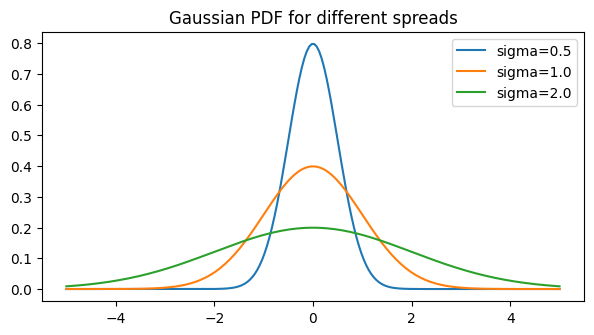

In [ ]:
#Gaussian
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample Mean: 1.9964


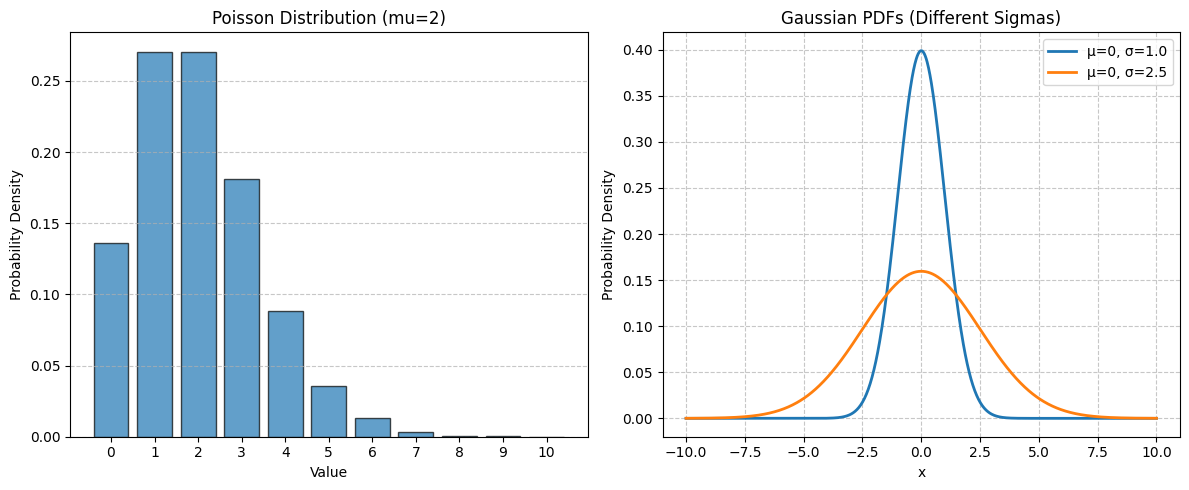

In [ ]:
#Lab Exercise: Probability Distributions
#Poisson
poisson_samples = np.random.poisson(lam=2, size=100_000)
sample_mean = np.mean(poisson_samples)
print(f"Sample Mean: {sample_mean:.4f}")
#Histogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
bins = np.arange(-0.5, poisson_samples.max() + 1.5, 1)
plt.hist(poisson_samples, bins=bins, density=True, rwidth=0.8, edgecolor='black', alpha=0.7)
plt.title("Poisson Distribution (mu=2)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.xticks(range(0, poisson_samples.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
#Gaussian
plt.subplot(1, 2, 2)
x = np.linspace(-10, 10, 1000)
mu = 0
sigma1 = 1.0
sigma2 = 2.5
pdf1 = stats.norm.pdf(x, loc=mu, scale=sigma1)
pdf2 = stats.norm.pdf(x, loc=mu, scale=sigma2)
plt.plot(x, pdf1, label=f"μ={mu}, σ={sigma1}", linewidth=2)
plt.plot(x, pdf2, label=f"μ={mu}, σ={sigma2}", linewidth=2)
plt.title("Gaussian PDFs (Different Sigmas)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Entropy
from scipy.stats import entropy
fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [ ]:
#KL Divergence
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [ ]:
#Mutual Information
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris
iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [ ]:
#Lab Exercise: Randomness
#Entropy
p_4 = np.array([1/4] * 4)
p_6 = np.array([1/6] * 6)
entropy_4 = stats.entropy(p_4, base=2)
entropy_6 = stats.entropy(p_6, base=2)
print(f"Entropy (4-sided die): {entropy_4:.4f} bits")
print(f"Entropy (6-sided die): {entropy_6:.4f} bits")
#KL Divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
kl_div = stats.entropy(P, Q, base=2)
#Iris
print(f"KL Divergence D(P || Q): {kl_div:.4f} bits")

Entropy (4-sided die): 2.0000 bits
Entropy (6-sided die): 2.5850 bits
KL Divergence D(P || Q): 0.1187 bits
